In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("adult.csv")
print(df.shape)
df.head()

(32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
df = df.replace("?", np.nan)

df = df.dropna().reset_index(drop=True)

print("After cleaning:", df.shape)

After cleaning: (30162, 15)


In [13]:
df["income"] = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

In [14]:
X = df.drop("income", axis=1)
y = df["income"]

In [15]:
X = pd.get_dummies(X, drop_first=True)

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, n_jobs=-1, random_state=42)

In [18]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8695508039118184
Precision: 0.7996647108130763
Recall   : 0.6351531291611185
F1 Score : 0.7079777365491651
ROC AUC  : 0.9245212224941893


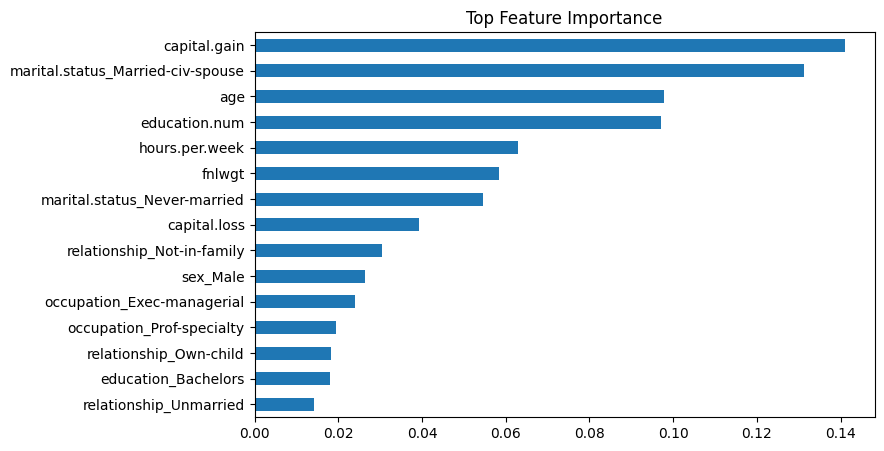

In [20]:
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns)
top_feats = feat_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,5))
top_feats.sort_values().plot(kind="barh")
plt.title("Top Feature Importance")
plt.show()